In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             f1_score, confusion_matrix, 
                             classification_report)
from sklearn.utils import resample
import shap

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [15]:
df = pd.read_csv('diabetic_data.csv')
print("Original shape:", df.shape)
print("Readmission counts:\n", df['readmitted'].value_counts())

Original shape: (101766, 50)
Readmission counts:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [16]:
df.replace('?', np.nan, inplace=True)

drop_cols = ['encounter_id', 'patient_nbr', 'weight', 
             'payer_code', 'medical_specialty',
             'examide', 'citoglipton']
df.drop(columns=drop_cols, inplace=True)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Cleaned shape:", df.shape)

Cleaned shape: (101766, 43)


In [17]:
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Target distribution:\n", df['readmitted'].value_counts())
print("Readmission rate:", round(df['readmitted'].mean() * 100, 2), "%")

Target distribution:
 readmitted
0    90409
1    11357
Name: count, dtype: int64
Readmission rate: 11.16 %


In [18]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done. Shape:", df.shape)

Encoding done. Shape: (101766, 43)


In [19]:
df_majority = df[df['readmitted'] == 0]
df_minority = df[df['readmitted'] == 1]

print("Before balancing:")
print("Not readmitted:", len(df_majority))
print("Readmitted <30:", len(df_minority))

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority) * 3,
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df_balanced['readmitted'].value_counts())

Before balancing:
Not readmitted: 90409
Readmitted <30: 11357

After balancing:
readmitted
0    34071
1    11357
Name: count, dtype: int64


In [20]:
X = df_balanced.drop('readmitted', axis=1)
y = df_balanced['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (36342, 42)
Test size: (9086, 42)


In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Done!")
print(classification_report(y_test, lr_pred))

Logistic Regression Done!
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      6815
           1       0.59      0.08      0.14      2271

    accuracy                           0.76      9086
   macro avg       0.67      0.53      0.50      9086
weighted avg       0.72      0.76      0.68      9086



In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest Done!")
print(classification_report(y_test, rf_pred))

Random Forest Done!
              precision    recall  f1-score   support

           0       0.76      0.98      0.86      6815
           1       0.62      0.08      0.14      2271

    accuracy                           0.76      9086
   macro avg       0.69      0.53      0.50      9086
weighted avg       0.73      0.76      0.68      9086



In [23]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGBoost Done!")
print(classification_report(y_test, xgb_pred))

XGBoost Done!
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      6815
           1       0.53      0.15      0.24      2271

    accuracy                           0.75      9086
   macro avg       0.65      0.55      0.55      9086
weighted avg       0.71      0.75      0.70      9086



In [24]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'AUC Score': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  AUC Score  F1 Score
Logistic Regression  0.756108   0.648447  0.142415
      Random Forest  0.758199   0.650969  0.144803
            XGBoost  0.753797   0.666990  0.238857


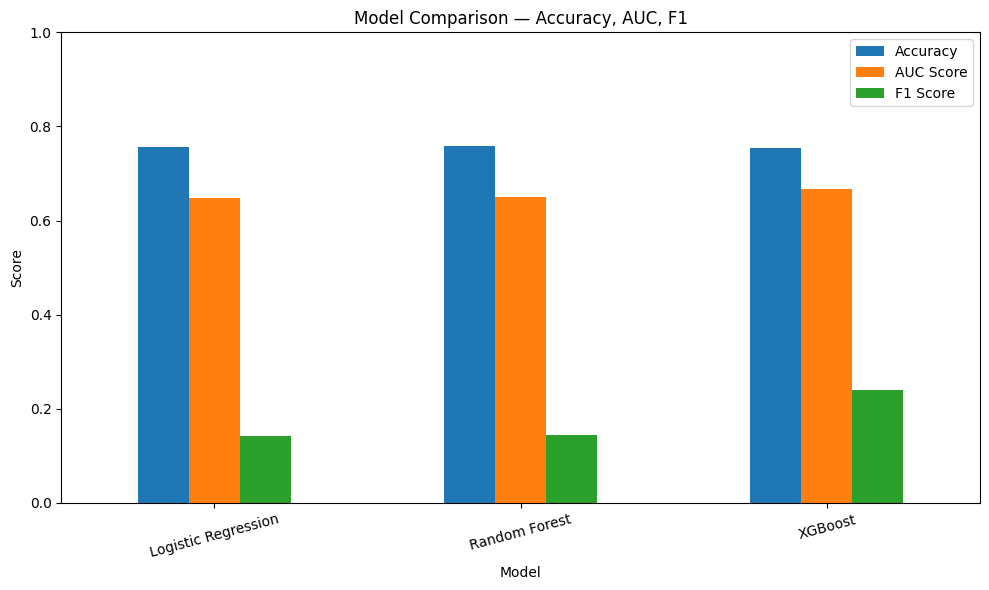

Chart saved!


In [25]:
results_df.set_index('Model').plot(kind='bar', figsize=(10,6), 
                                    color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Model Comparison — Accuracy, AUC, F1')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

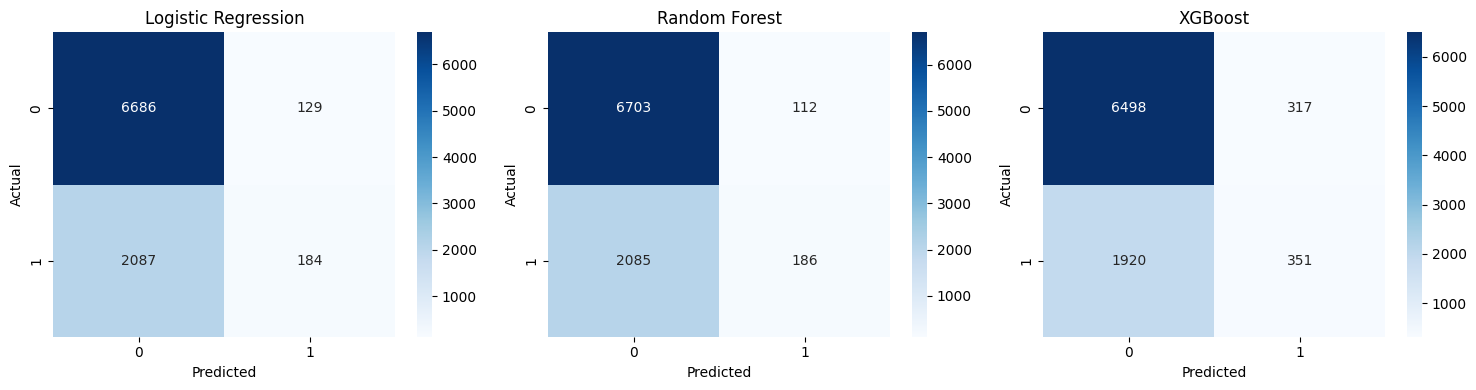

Confusion matrices saved!


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
preds = [lr_pred, rf_pred, xgb_pred]

for ax, model_name, pred in zip(axes, models, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved!")

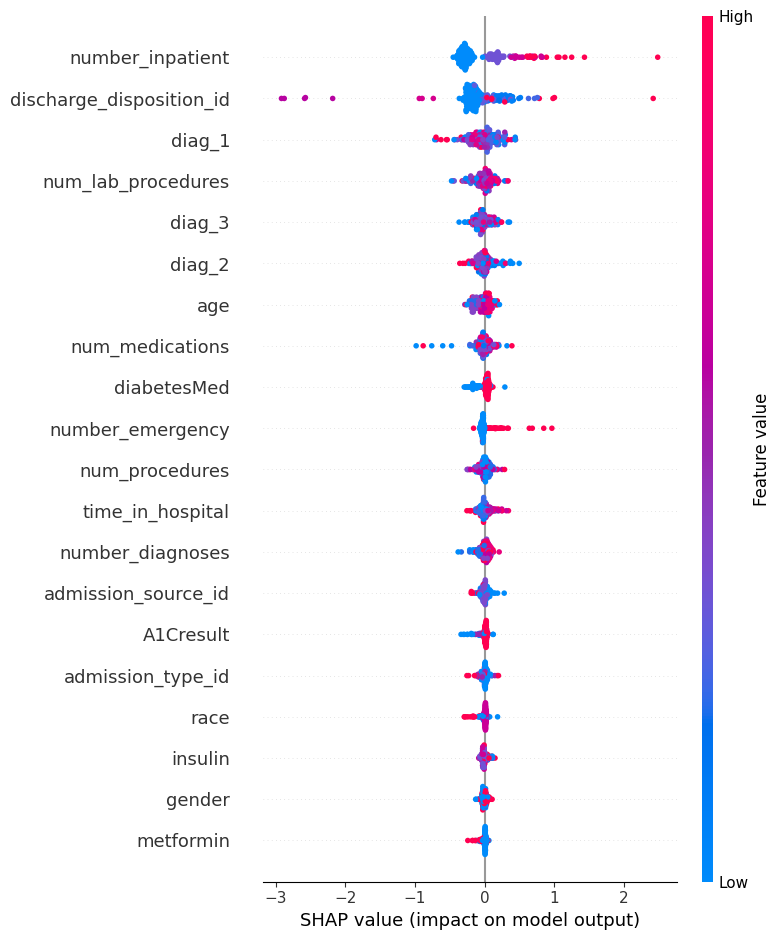

SHAP plot saved!


In [27]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:200])

plt.figure()
shap.summary_plot(shap_values, X_test[:200], show=False)
plt.tight_layout()
plt.savefig('shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

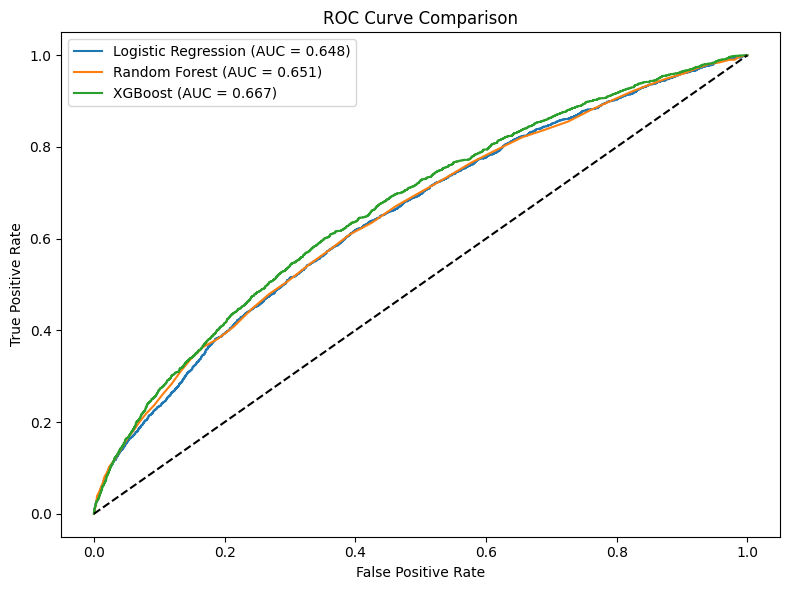

ROC curve saved!


In [28]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, prob in zip(['Logistic Regression', 'Random Forest', 'XGBoost'],
                       [lr_prob, rf_prob, xgb_prob]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("ROC curve saved!")